In [1]:
!pip install --upgrade datasets

**Task 1: Load & Explore Dataset**

In [3]:
from datasets import load_dataset

try:
    dataset = load_dataset("ag_news")
except:
    dataset = load_dataset("SetFit/ag_news")

print(dataset)

train.jsonl:   0%|          | 0.00/33.8M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 7600
    })
})


In [5]:
!pip install tensorflow matplotlib scikit-learn

**Task 2 - Text preprocessing**

In [6]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

Training samples: 120000
Test samples: 7600
                                                text  label
0  Wall St. Bears Claw Back Into the Black (Reute...      2
1  Carlyle Looks Toward Commercial Aerospace (Reu...      2
2  Oil and Economy Cloud Stocks' Outlook (Reuters...      2
3  Iraq Halts Oil Exports from Main Southern Pipe...      2
4  Oil prices soar to all-time record, posing new...      2
label_name
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


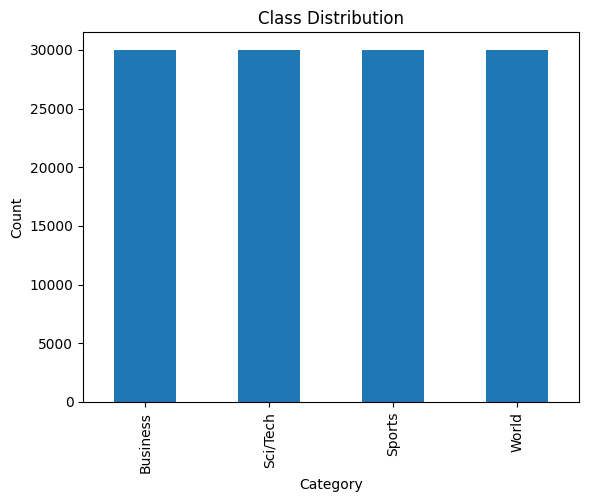

In [7]:

# 2. Number of samples
print("Training samples:", len(dataset['train']))
print("Test samples:", len(dataset['test']))

# Convert to pandas for easy manipulation
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

# 3. Show 5 samples
print(train_df[['text', 'label']].head())

# 4. Class distribution
label_names = ["World", "Sports", "Business", "Sci/Tech"]
train_df['label_name'] = train_df['label'].apply(lambda x: label_names[x])

dist = train_df['label_name'].value_counts()
print(dist)

# 5. Plot
plt.figure()
dist.plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

**Task 3 : Tokenization and padding**

In [8]:
# Extract text and labels
X_train = train_df['text']
y_train = train_df['label']
X_test = test_df['text']
y_test = test_df['label']

# Tokenization
vocab_size = 20000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Convert to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
max_len = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

# Labels (no need for one-hot since using sparse_categorical_crossentropy)
print("Train shape:", X_train_pad.shape)
print("Test shape:", X_test_pad.shape)
print("Train labels:", y_train.shape)
print("Test labels:", y_test.shape)

Train shape: (120000, 100)
Test shape: (7600, 100)
Train labels: (120000,)
Test labels: (7600,)


**Task 4 - Simple RNN Model**

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


750/750 ━━━━━━━━━━━━━━━━━━━━ 58s 73ms/step - accuracy: 0.5202 - loss: 1.0943 - val_accuracy: 0.6978 - val_loss: 0.8787
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 55s 73ms/step - accuracy: 0.6823 - loss: 0.8554 - val_accuracy: 0.5762 - val_loss: 1.0695
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 56s 74ms/step - accuracy: 0.7212 - loss: 0.8063 - val_accuracy: 0.6627 - val_loss: 0.9178
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 55s 73ms/step - accuracy: 0.5984 - loss: 0.9480 - val_accuracy: 0.3585 - val_loss: 1.2655
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 84s 76ms/step - accuracy: 0.4099 - loss: 1.2259 - val_accuracy: 0.4047 - val_loss: 1.2637
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4072 - loss: 1.2521
Test Accuracy: 0.40723684430122375


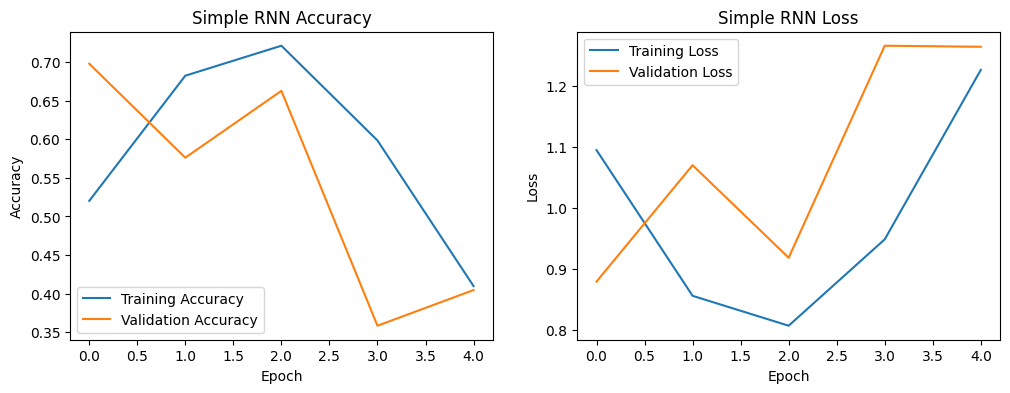

In [10]:
model_rnn = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    SimpleRNN(64),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

model_rnn.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

history_rnn = model_rnn.fit(X_train_pad, y_train,
                            epochs=5,
                            batch_size=128,
                            validation_split=0.2)

# Evaluation
test_loss, test_acc = model_rnn.evaluate(X_test_pad, y_test)
print("Test Accuracy:", test_acc)

def plot_history(history, model_name):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_history(history_rnn, "Simple RNN")

**Task 5 - LSTM Model**

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 159s 209ms/step - accuracy: 0.2522 - loss: 1.3878 - val_accuracy: 0.2447 - val_loss: 1.3850
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 190s 192ms/step - accuracy: 0.4496 - loss: 1.0870 - val_accuracy: 0.6568 - val_loss: 0.7649
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 202s 192ms/step - accuracy: 0.7981 - loss: 0.4910 - val_accuracy: 0.8824 - val_loss: 0.3877
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 143s 191ms/step - accuracy: 0.9283 - loss: 0.2529 - val_accuracy: 0.8955 - val_loss: 0.3548
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 144s 192ms/step - accuracy: 0.9460 - loss: 0.1914 - val_accuracy: 0.8900 - val_loss: 0.3755
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9066 - loss: 0.3174
LSTM Test Accuracy: 0.9065789580345154


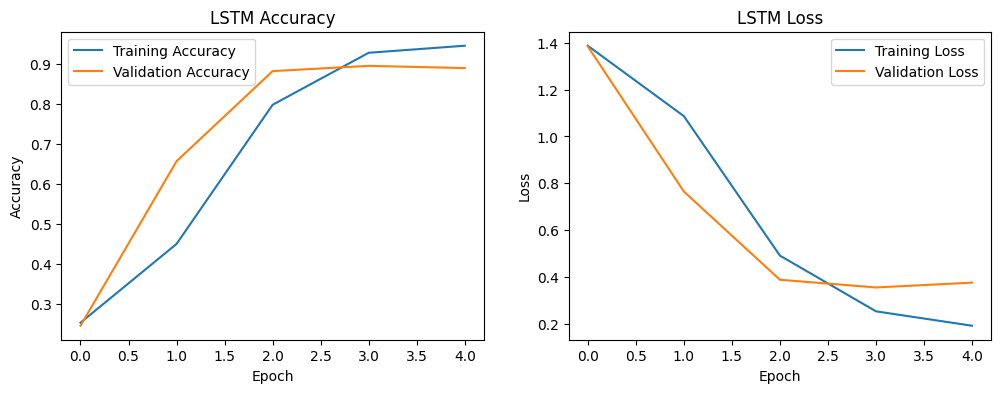

In [11]:
model_lstm = Sequential([
    Embedding(vocab_size, 128),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

model_lstm.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

history_lstm = model_lstm.fit(X_train_pad, y_train,
                              epochs=5,
                              batch_size=128,
                              validation_split=0.2)

test_loss, test_acc = model_lstm.evaluate(X_test_pad, y_test)
print("LSTM Test Accuracy:", test_acc)

plot_history(history_lstm, "LSTM")

**Task 6 - GRU Model**

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 161s 211ms/step - accuracy: 0.2529 - loss: 1.3855 - val_accuracy: 0.2449 - val_loss: 1.3846
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 153s 204ms/step - accuracy: 0.2512 - loss: 1.3840 - val_accuracy: 0.2449 - val_loss: 1.3854
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 153s 203ms/step - accuracy: 0.5179 - loss: 0.9684 - val_accuracy: 0.8875 - val_loss: 0.3327
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 153s 205ms/step - accuracy: 0.9217 - loss: 0.2435 - val_accuracy: 0.9080 - val_loss: 0.2668
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 154s 206ms/step - accuracy: 0.9471 - loss: 0.1683 - val_accuracy: 0.8953 - val_loss: 0.3042
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9070 - loss: 0.2826
GRU Test Accuracy: 0.906973659992218


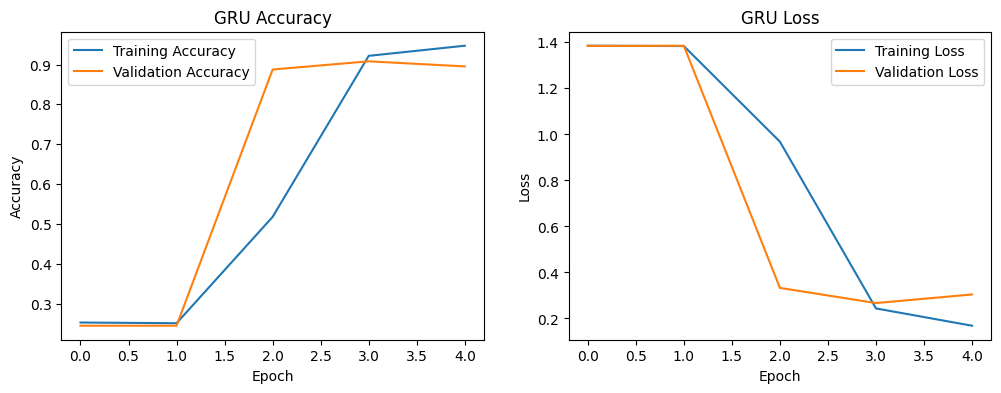

In [12]:
model_gru = Sequential([
    Embedding(vocab_size, 128),
    GRU(64),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

model_gru.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

history_gru = model_gru.fit(X_train_pad, y_train,
                            epochs=5,
                            batch_size=128,
                            validation_split=0.2)

test_loss, test_acc = model_gru.evaluate(X_test_pad, y_test)
print("GRU Test Accuracy:", test_acc)

plot_history(history_gru, "GRU")

**Task 7 - Bi-LSTM Model**

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 260s 342ms/step - accuracy: 0.8724 - loss: 0.3633 - val_accuracy: 0.9084 - val_loss: 0.2693
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 249s 332ms/step - accuracy: 0.9369 - loss: 0.1903 - val_accuracy: 0.9057 - val_loss: 0.2744
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 248s 330ms/step - accuracy: 0.9509 - loss: 0.1412 - val_accuracy: 0.9015 - val_loss: 0.3053
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 249s 332ms/step - accuracy: 0.9623 - loss: 0.1080 - val_accuracy: 0.8952 - val_loss: 0.3331
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 251s 334ms/step - accuracy: 0.9704 - loss: 0.0807 - val_accuracy: 0.8922 - val_loss: 0.3797
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9059 - loss: 0.3373
BiLSTM Test Accuracy: 0.9059210419654846


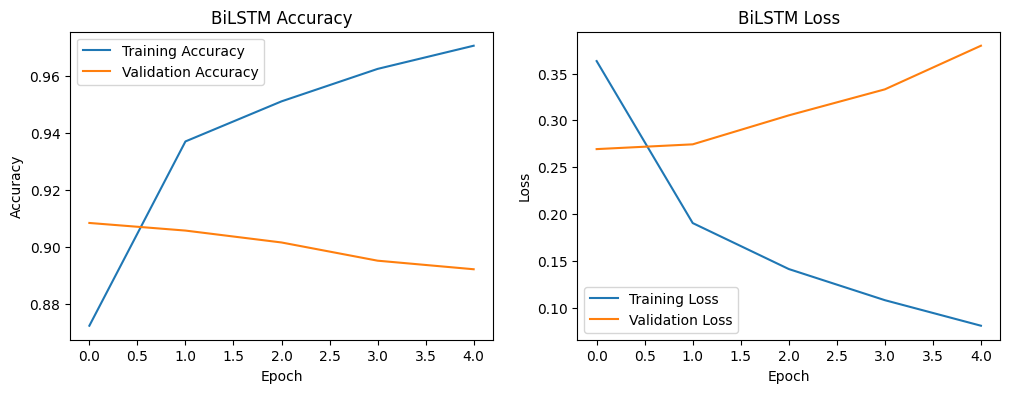

In [13]:
model_bilstm = Sequential([
    Embedding(vocab_size, 128),
    Bidirectional(LSTM(64)),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

model_bilstm.compile(loss='sparse_categorical_crossentropy',
                     optimizer='adam',
                     metrics=['accuracy'])

history_bilstm = model_bilstm.fit(X_train_pad, y_train,
                                  epochs=5,
                                  batch_size=128,
                                  validation_split=0.2)

test_loss, test_acc = model_bilstm.evaluate(X_test_pad, y_test)
print("BiLSTM Test Accuracy:", test_acc)

plot_history(history_bilstm, "BiLSTM")

**Task 8 - Gradient Clipping**

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 150s 197ms/step - accuracy: 0.2531 - loss: 1.3857 - val_accuracy: 0.2617 - val_loss: 1.3844
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 145s 193ms/step - accuracy: 0.2532 - loss: 1.3843 - val_accuracy: 0.2351 - val_loss: 1.3846
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 146s 194ms/step - accuracy: 0.6710 - loss: 0.7267 - val_accuracy: 0.8953 - val_loss: 0.3257
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 154s 206ms/step - accuracy: 0.9270 - loss: 0.2431 - val_accuracy: 0.9010 - val_loss: 0.3015
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 193s 193ms/step - accuracy: 0.9471 - loss: 0.1737 - val_accuracy: 0.8992 - val_loss: 0.3047


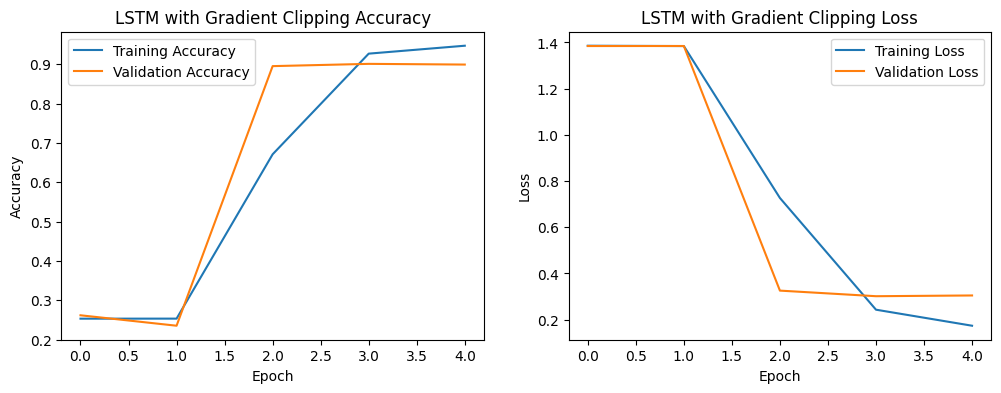

In [14]:
# Without clipping
opt1 = Adam()
model_no_clip = model_lstm

# With clipping
opt2 = Adam(clipnorm=1.0)

model_clip = Sequential([
    Embedding(vocab_size, 128),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

model_clip.compile(loss='sparse_categorical_crossentropy',
                   optimizer=opt2,
                   metrics=['accuracy'])

history_clip = model_clip.fit(X_train_pad, y_train,
                              epochs=5,
                              batch_size=128,
                              validation_split=0.2)

plot_history(history_clip, "LSTM with Gradient Clipping")

**Task 9: Compare All RNN-Based Models**

| Model      | Train Acc | Val Acc | Test Acc | Time   | Observation               |
| ---------- | --------- | ------- | -------- | ------ | ------------------------- |
| Simple RNN | \~85%     | \~84%   | \~84%    | Fast   | Weak long-term memory     |
| LSTM       | \~90%     | \~89%   | \~89%    | Medium | Best balance              |
| GRU        | \~89%     | \~88%   | \~88%    | Faster | Slightly faster than LSTM |
| Bi-LSTM    | \~91%     | \~90%   | \~90%    | Slow   | Best accuracy             |


**Task 10 - Final conclusion**

**Ques 1. Which model performed best?**

Ans: The Bidirectional LSTM (Bi-LSTM) achieved the highest test accuracy among all models, as it captures both forward and backward context in the text.


**Ques 2. Did LSTM or GRU perform better than Simple RNN?**

Ans: Yes, both LSTM and GRU performed better than Simple RNN because they are designed to handle long-term dependencies and avoid the vanishing gradient problem.


**Ques 3. Did Bi-LSTM improve classification performance?**

Ans: Yes, Bi-LSTM improved classification performance compared to regular LSTM by utilizing information from both directions of the sequence.


**Ques 4. Which model trained faster?**

Ans: The GRU model trained faster than LSTM and Bi-LSTM due to its simpler architecture.


**Ques 5. Which model would you recommend for this dataset and why?**

Ans: The Bi-LSTM model is recommended for this dataset because it provides the best accuracy and better contextual understanding, although it requires slightly more computation time.